# Pipeline v4 — Um modelo por área anatômica (50% vs 75%)

Em vez de misturar as áreas numa linha só (v2) ou tratá-las como linhas separadas
dentro do mesmo modelo (v1/v3), esta versão treina **um modelo independente por
área anatômica** (CA3b, CA3c, DGD, DGV). Isso resolve a pseudoreplicação
**por construção**: dentro de cada modelo, cada trial aparece no máximo 1 vez (só se
aquela área foi registrada nele) -- não precisa agregar nada depois.

**O que isso responde a mais que a v1:** não só "existe sinal?", mas **"em qual área
o sinal é mais forte?"** -- uma pergunta mais rica, mas que exige cuidado extra:

- **Comparações múltiplas**: rodar 4 modelos (1 por área) e destacar qual "deu
  significativo" é mais fácil de acontecer por acaso do que parece. O teste de
  permutação da Seção 6 aplica a **correção de Bonferroni** (limiar de significância
  dividido por 4 -- `0.05 / 4 = 0.0125` -- em vez do 0.05 de costume).
- **N menor e variável por área**: um trial só entra no modelo de uma área se aquela
  área foi de fato registrada nele -- o N de cada área pode ser bem diferente.

Herda da v1: CV aninhada (Pontos 2 e 3 já corrigidos), `N_BINS_GRID` no lugar de
`passo_pct` (Ponto 4), filtro de NOR pela coluna `condicao` (Ponto 8), `n_jobs`
corrigido. Classificação **binária (50% vs 75%)**, como a v1.

> Também salva, para cada área x modelo: a **matriz de confusão** (PNG) e a
> **interpretação SHAP** (gráfico summary + CSV de importância média) do modelo
> final de cada área.

> ⚠️ **Custo computacional**: isso multiplica o tempo de execução por ~4 (uma CV
> aninhada inteira por área). As grades de hiperparâmetro foram deixadas moderadas de
> propósito -- amplie com cautela.

> Este notebook **não foi executado aqui** — não tenho acesso aos seus arquivos de dados.
> Rode do zero no seu ambiente.

## 1. Configuração e Carregamento dos Dados

In [ ]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 303.4/303.4 MB 13.3 MB/s eta 0:00:00


In [ ]:
pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 498.0/498.0 kB 21.2 MB/s eta 0:00:00


In [ ]:
import json
import os
import time
import warnings
from pathlib import Path

os.environ["PYTHONWARNINGS"] = "ignore"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut, GridSearchCV
from sklearn.ensemble import RandomForestClassifier  # usado também como selector interno do SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from sklearn.base import clone
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)

try:
    import shap
    SHAP_DISPONIVEL = True
except ImportError:
    SHAP_DISPONIVEL = False
    print("Pacote 'shap' não encontrado. Instale com: pip install shap")

try:
    from xgboost import XGBClassifier
    XGBOOST_DISPONIVEL = True
except ImportError:
    XGBOOST_DISPONIVEL = False
    print("Pacote 'xgboost' não encontrado. Instale com: pip install xgboost")

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".*should be used with.*Parallel.*")
sns.set_theme(style="whitegrid", font_scale=0.9)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

TOP_N_FEATURES_GRID = [10, 15, 20, 25]

CAMINHOS_CANDIDATOS = [
    Path("/content/features_all.csv"), # Updated path as requested
    Path("databases/features_all.csv"),
]

DURACAO_MINIMA_S = 30

FEATURE_BOOLEANA = "pac_sl_alerta"
FEATURES_POR_AREA = [
    "mean", "std", "rms", "kurtosis", "skewness", "pico_a_pico", "pct_outlier_3s",
    "pot_delta", "pot_theta", "pot_beta", "pot_gamma_lento", "pot_gamma_rapido",
    "theta_gamma_lento_ratio", "theta_gamma_rapido_ratio", "delta_theta_ratio",
    "entropia_espectral", "centroide_hz",
    "pac_theta-gamma_rapido", "pac_theta-gamma_lento", "pac_sl_alerta",
]

# Grade moderada por causa do custo ×4 (uma CV aninhada por área) -- amplie com
# cautela se tiver tempo de sobra.
N_BINS_GRID = [2, 3, 4, 5, 8]
print(f"Candidatos de n_bins a testar: {N_BINS_GRID}")

# Binário: 50% vs 75% (mesmo escopo da v1)
CONDICOES_ALVO = [50, 75]

caminho_dados = next((p for p in CAMINHOS_CANDIDATOS if p.exists()), None)
if caminho_dados is None:
    raise FileNotFoundError(
        "features_all não encontrado. Ajuste CAMINHOS_CANDIDATOS para apontar "
        "para o seu features_all.parquet ou features_all.csv."
    )

if caminho_dados.suffix == ".parquet":
    df_bruto = pd.read_parquet(caminho_dados)
else:
    df_bruto = pd.read_csv(caminho_dados)

print(f" Carregado: {caminho_dados}")
print(f"   Shape: {df_bruto.shape[0]:,} linhas × {df_bruto.shape[1]} colunas")

pasta_resultados = Path("resultados_por_area_v4")
pasta_resultados.mkdir(exist_ok=True)
print(f"   Resultados serão salvos em: {pasta_resultados.resolve()}")

Candidatos de n_bins a testar: [2, 3, 4, 5, 8]
 Carregado: /content/features_all.csv
   Shape: 19,028 linhas × 105 colunas
   Resultados serão salvos em: /content/resultados_por_area_v4


## 2. Limpeza dos Dados

Mesmo filtro de NOR corrigido da v1/v2/v3: critério primário pela coluna `condicao`,
com `.str.contains("nor")` como camada extra, mais o filtro de 25% (já que aqui é
binário) e o `assert` final.

In [ ]:
duracao_por_stem = df_bruto.groupby("stem")["segundo"].max()
stems_curtos = duracao_por_stem[duracao_por_stem < DURACAO_MINIMA_S]

n_arquivos_antes = df_bruto["stem"].nunique()

condicao_numerica = pd.to_numeric(df_bruto["condicao"], errors="coerce")
condicoes_validas = {c / 100 for c in CONDICOES_ALVO}
mask_condicao_valida = condicao_numerica.apply(lambda v: any(np.isclose(v, c, atol=1e-6) for c in condicoes_validas))
stems_condicao_invalida = df_bruto.loc[~mask_condicao_valida, "stem"].unique()

stems_nor_por_nome = df_bruto.loc[
    df_bruto["stem"].str.contains("nor", case=False, na=False), "stem"
].unique()

stems_para_remover = set(stems_condicao_invalida) | set(stems_nor_por_nome) | set(stems_curtos.index)

df_limpo = df_bruto[~df_bruto["stem"].isin(stems_para_remover)].copy()

n_arquivos_depois = df_limpo["stem"].nunique()

print("=" * 60)
print(f"Arquivos antes das exclusões          : {n_arquivos_antes}")
print(f"Arquivos com condição inválida (NOR/25%): {len(stems_condicao_invalida)}")
print(f"Arquivos com 'nor' no nome (extra)     : {len(stems_nor_por_nome)}")
print(f"Arquivos < {DURACAO_MINIMA_S}s removidos          : {len(stems_curtos)}")
print(f"Arquivos após as exclusões             : {n_arquivos_depois}")
print("=" * 60)

AREAS = sorted({c[:-len("_mean")] for c in df_limpo.columns if c.endswith("_mean")})
print(f"\nÁreas anatômicas encontradas ({len(AREAS)}): {AREAS}")

condicoes_restantes = sorted(pd.to_numeric(df_limpo["condicao"], errors="coerce").dropna().unique())
print(f"Condições restantes no dataset: {condicoes_restantes}  (deve conter só 0.5 e 0.75)")
assert set(np.round(condicoes_restantes, 2)) <= {0.5, 0.75}, (
    "Ainda há condições fora de {50%, 75%} em df_limpo -- confira a coluna 'condicao'."
)

# Quantos trials cada área tem registrados -- ajuda a entender o N por área
# antes mesmo de rodar qualquer modelo.
for area in AREAS:
    col_ref = f"{area}_mean"
    n_trials_area = df_limpo.loc[df_limpo[col_ref].notna(), "stem"].nunique()
    print(f"  {area}: {n_trials_area} trials com essa área registrada")


Arquivos antes das exclusões          : 93
Arquivos com condição inválida (NOR/25%): 47
Arquivos com 'nor' no nome (extra)     : 22
Arquivos < 30s removidos          : 3
Arquivos após as exclusões             : 44

Áreas anatômicas encontradas (4): ['CA3b', 'CA3c', 'DGD', 'DGV']
Condições restantes no dataset: [np.float64(0.5), np.float64(0.75)]  (deve conter só 0.5 e 0.75)
  CA3b: 40 trials com essa área registrada
  CA3c: 41 trials com essa área registrada
  DGD: 43 trials com essa área registrada
  DGV: 42 trials com essa área registrada


## 3. Engenharia de Atributos — versão por área única

Diferente da v1 (que gera todas as áreas numa função só, com dummy), aqui cada
função recebe **uma única área** por vez. Isso evita a pseudoreplicação por
construção: o resultado tem **no máximo 1 linha por trial** (só se aquela área foi
registrada nele) -- não tem dummy de área (não faz sentido com 1 área só) nem
necessidade de agregar nada depois.

In [ ]:
def atribuir_faixa_percentual(n_segundos, n_bins):
    posicao_relativa = (np.arange(n_segundos) + 1) / n_segundos
    faixa = np.ceil(posicao_relativa * n_bins).astype(int)
    return np.clip(faixa, 1, n_bins)


def transformar_wide_area_unica(df_long, area, features_por_area, n_bins):
    """Igual a transformacao wide da v1, mas restrita a UMA area -- gera no
    maximo 1 linha por trial (so se `area` foi registrada nele)."""
    passo_pct = 100 // n_bins
    rotulos_pct = [passo_pct * b for b in range(1, n_bins + 1)]

    df_long = df_long.sort_values(["stem", "segundo"]).copy()
    linhas_resultado = []

    for stem, grupo in df_long.groupby("stem", sort=False):
        col_ref = f"{area}_mean"
        area_registrada = col_ref in grupo.columns and grupo[col_ref].notna().any()
        if not area_registrada:
            continue

        grupo = grupo.sort_values("segundo")
        grupo = grupo.assign(_faixa_pct=atribuir_faixa_percentual(len(grupo), n_bins))

        rato = grupo["rato"].iloc[0]
        trial = grupo["trial"].iloc[0]
        condicao = grupo["condicao"].iloc[0]

        linha = {"stem": stem, "rato": rato, "trial": trial,
                 "condicao": condicao, "duracao_s": len(grupo)}

        for feature in features_por_area:
            if feature == FEATURE_BOOLEANA:
                continue
            coluna = f"{area}_{feature}"
            if coluna not in grupo.columns:
                continue
            for faixa, pct in zip(range(1, n_bins + 1), rotulos_pct):
                valores = grupo.loc[grupo["_faixa_pct"] == faixa, coluna]
                linha[f"{feature}_mean_{pct}pct"] = valores.mean()
                linha[f"{feature}_std_{pct}pct"] = valores.std() if len(valores) > 1 else np.nan
                linha[f"{feature}_min_{pct}pct"] = valores.min() if len(valores) else np.nan
                linha[f"{feature}_max_{pct}pct"] = valores.max() if len(valores) else np.nan
                linha[f"{feature}_median_{pct}pct"] = valores.median()

        coluna_bool = f"{area}_{FEATURE_BOOLEANA}"
        if coluna_bool in grupo.columns:
            for faixa, pct in zip(range(1, n_bins + 1), rotulos_pct):
                valores = grupo.loc[grupo["_faixa_pct"] == faixa, coluna_bool]
                linha[f"{FEATURE_BOOLEANA}_true_rate_{pct}pct"] = (
                    (valores == True).mean() if len(valores) else np.nan
                )

        linhas_resultado.append(linha)

    return pd.DataFrame(linhas_resultado)


def remover_colunas_correlacionadas(X_ref, limiar=0.8):
    """Identifica atributos com |correlacao| > limiar. Sem colunas protegidas
    aqui -- nao existe dummy de area nessa versao (1 area so por modelo)."""
    corr = X_ref.corr().abs()
    mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
    upper = corr.where(mask)
    return [c for c in upper.columns if any(upper[c] > limiar)]


def _montar_wide_area_com_derivadas(df_long, area, n_bins):
    df_pct = transformar_wide_area_unica(df_long, area, FEATURES_POR_AREA, n_bins=n_bins)
    if df_pct.empty:
        return df_pct

    features_continuas = [f for f in FEATURES_POR_AREA if f != FEATURE_BOOLEANA]
    passo_pct_real = 100 // n_bins
    pcts = [passo_pct_real * b for b in range(1, n_bins + 1)]

    for feature in features_continuas:
        cols = [c for c in (f"{feature}_mean_{p}pct" for p in pcts) if c in df_pct.columns]
        if cols:
            df_pct[f"{feature}_media_geral"] = df_pct[cols].mean(axis=1)

    cols_bool = [c for c in (f"pac_sl_alerta_true_rate_{p}pct" for p in pcts) if c in df_pct.columns]
    if cols_bool:
        df_pct["pac_sl_alerta_taxa_geral"] = df_pct[cols_bool].mean(axis=1)

    df_pct["condicao"] = pd.to_numeric(df_pct["condicao"])
    df_pct = df_pct.drop(columns=["trial", "duracao_s"])
    return df_pct


def montar_dataset_modelagem_area(df_long_limpo, area, n_bins, verbose=True):
    """Reproduz a engenharia completa para UMA area e um dado `n_bins`, usando
    TODOS os dados recebidos. Usada para o "modelo final" de interpretacao
    (SHAP) -- NAO usada para reportar acuracia."""
    df_pct = _montar_wide_area_com_derivadas(df_long_limpo, area, n_bins)
    if df_pct.empty or len(df_pct) < 4:
        return None, None, None, None, []

    groups = df_pct["rato"]
    stems = df_pct["stem"]
    y = df_pct["condicao"]
    X = df_pct.drop(columns=["rato", "condicao", "stem"], errors="ignore")

    colunas_removidas = remover_colunas_correlacionadas(X)
    features_finais = [c for c in X.columns if c not in colunas_removidas]
    X_final = X[features_finais]

    if verbose:
        print(f"    [{area} | n_bins={n_bins}] atributos: {X.shape[1]} -> {X_final.shape[1]} "
              f"({len(colunas_removidas)} removidos por correlacao) | {len(X_final)} trials")

    return X_final, y, groups, stems, colunas_removidas


def montar_dataset_treino_teste_area(df_treino_long, df_teste_long, area, n_bins):
    """Monta treino e teste SEPARADAMENTE para um fold da CV aninhada, para
    UMA area. Correlacao decidida so com o treino -- sem vazamento.

    NOTA (adicionado para a analise de erros da Secao 9): tambem devolve
    `stems_teste`, o identificador de cada trial de teste, na MESMA ordem de
    `y_teste` -- e o que permite depois rastrear, trial a trial, se o modelo
    acertou ou errou (e de qual rato/stem veio o erro)."""
    df_pct_treino = _montar_wide_area_com_derivadas(df_treino_long, area, n_bins)
    df_pct_teste = _montar_wide_area_com_derivadas(df_teste_long, area, n_bins)

    if df_pct_treino.empty or df_pct_teste.empty:
        return None, None, None, None, None, None, None

    groups_treino = df_pct_treino["rato"]
    y_treino = df_pct_treino["condicao"]
    X_treino = df_pct_treino.drop(columns=["rato", "condicao", "stem"], errors="ignore")

    groups_teste = df_pct_teste["rato"]
    y_teste = df_pct_teste["condicao"]
    stems_teste = df_pct_teste["stem"]
    X_teste = df_pct_teste.drop(columns=["rato", "condicao", "stem"], errors="ignore")

    colunas_removidas = remover_colunas_correlacionadas(X_treino)
    features_finais = [c for c in X_treino.columns if c not in colunas_removidas]
    features_finais = [c for c in features_finais if c in X_teste.columns]

    X_treino_final = X_treino[features_finais]
    X_teste_final = X_teste[features_finais]

    return X_treino_final, y_treino, groups_treino, X_teste_final, y_teste, groups_teste, stems_teste


print("Funcoes de engenharia de atributos por area unica definidas.")


Funcoes de engenharia de atributos por area unica definidas.


## 4. Funções Genéricas — Pipeline + CV Aninhada (parametrizadas por área)

Mesma lógica de CV aninhada da v1 (Pontos 2 e 3), agora recebendo `area` como
parâmetro -- a mesma função é reaproveitada para as 4 áreas na Seção 5, em vez de
copiar o código 4 vezes.

In [ ]:
def montar_pipeline(estimator, usar_selecao_features=True, selector_estimator=None):
    """Pipeline generico: StandardScaler -> SelectFromModel -> estimator."""
    passos = [("scaler", StandardScaler())]
    if usar_selecao_features:
        sel_est = selector_estimator or RandomForestClassifier(
            n_estimators=300, max_depth=5, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=1,
        )
        passos.append(("selector", SelectFromModel(sel_est, threshold=-np.inf, max_features=20)))
    passos.append(("clf", estimator))
    return Pipeline(passos)


def _scorer_balanced_accuracy_silencioso(estimator, X, y):
    y_pred = estimator.predict(X)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=UserWarning)
        return balanced_accuracy_score(y, y_pred)


def escolher_configuracao_interna(df_treino_long, area, estimator, param_grid_semsel, param_grid_comsel,
                                   n_bins_grid, y_transformer=None, rotulo="modelo"):
    """CV INTERNA (por area): escolhe n_bins, com/sem selecao e hiperparametros
    usando so os ratos de treino deste fold externo."""
    y_transformer = y_transformer or (lambda y: y)
    logo_interno = LeaveOneGroupOut()

    melhor_global = None

    for n_bins in n_bins_grid:
        X_pct, y_pct, groups_pct, _, _ = montar_dataset_modelagem_area(df_treino_long, area, n_bins, verbose=False)
        if X_pct is None or groups_pct.nunique() < 2:
            continue
        y_pct = y_transformer((y_pct * 100).round().astype(int))

        cv_splits_interno = list(logo_interno.split(X_pct, y_pct, groups=groups_pct))
        if len(cv_splits_interno) < 2:
            continue

        pipe_semsel = montar_pipeline(clone(estimator), usar_selecao_features=False)
        busca_semsel = GridSearchCV(
            pipe_semsel, param_grid=param_grid_semsel, scoring=_scorer_balanced_accuracy_silencioso,
            cv=cv_splits_interno, n_jobs=-1, refit=False,
        )
        busca_semsel.fit(X_pct, y_pct)
        candidatos = [(busca_semsel.best_score_, n_bins, False, dict(busca_semsel.best_params_))]

        pipe_comsel = montar_pipeline(clone(estimator), usar_selecao_features=True)
        busca_comsel = GridSearchCV(
            pipe_comsel, param_grid=param_grid_comsel, scoring=_scorer_balanced_accuracy_silencioso,
            cv=cv_splits_interno, n_jobs=-1, refit=False,
        )
        busca_comsel.fit(X_pct, y_pct)
        candidatos.append((busca_comsel.best_score_, n_bins, True, dict(busca_comsel.best_params_)))

        for cand in candidatos:
            if melhor_global is None or cand[0] > melhor_global[0]:
                melhor_global = cand

    if melhor_global is None:
        return None

    score, n_bins, usa_selecao, params = melhor_global
    print(f"      [{rotulo}] config interna: n_bins={n_bins} | selecao={'com' if usa_selecao else 'sem'} "
          f"| CV interna={score:.3f} | params={params}")
    return {"n_bins": n_bins, "usa_selecao": usa_selecao, "params": params}


def treinar_avaliar_aninhado_area(df_long_limpo, area, nome_modelo, estimator, param_grid_semsel, param_grid_comsel,
                                   n_bins_grid=None, y_transformer=None, inverse_label_fn=None):
    """CV aninhada (nested Leave-One-Rat-Out) para UMA area."""
    n_bins_grid = n_bins_grid or N_BINS_GRID
    y_transformer = y_transformer or (lambda y: y)
    ratos_com_area = sorted(
        df_long_limpo.loc[df_long_limpo[f"{area}_mean"].notna(), "rato"].unique()
    )
    labels_multi = sorted(y_transformer(pd.Series(CONDICOES_ALVO)).tolist())

    resultados_fold, configs_fold = [], []
    y_true_all, y_pred_all = [], []
    predicoes_fold = []  # NOVO (Secao 9): 1 linha por trial de teste -- area, modelo,
                          # fold, rato, stem, y_true, y_pred, acertou.

    for i, rato_teste in enumerate(ratos_com_area, start=1):
        df_treino_long = df_long_limpo[df_long_limpo["rato"] != rato_teste]
        df_teste_long = df_long_limpo[df_long_limpo["rato"] == rato_teste]

        config = escolher_configuracao_interna(
            df_treino_long, area, estimator, param_grid_semsel, param_grid_comsel,
            n_bins_grid, y_transformer=y_transformer, rotulo=f"{nome_modelo}/{area}",
        )
        if config is None:
            print(f"    [{nome_modelo}/{area}] fold {i}: sem ratos de treino suficientes -- pulando.")
            continue
        configs_fold.append({"rato_teste": rato_teste, **config})

        saida = montar_dataset_treino_teste_area(df_treino_long, df_teste_long, area, config["n_bins"])
        if saida[0] is None:
            continue
        X_tr, y_tr, _, X_te, y_te, _, stems_te = saida
        y_tr = y_transformer((y_tr * 100).round().astype(int))
        y_te = y_transformer((y_te * 100).round().astype(int))

        pipe = montar_pipeline(clone(estimator), config["usa_selecao"])
        pipe.set_params(**config["params"])
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=UserWarning)
            bal_acc = balanced_accuracy_score(y_te, y_pred)
        f1_macro = f1_score(y_te, y_pred, labels=labels_multi, average="macro", zero_division=0)

        y_true_all.extend(y_te.tolist())
        y_pred_all.extend(list(y_pred))

        # NOVO (Secao 9): decodifica de volta para 50/75 (identidade p/ RF e
        # LogReg; MAPA_XGB_INV p/ XGBoost) e guarda 1 linha por trial de teste.
        if inverse_label_fn is not None:
            y_te_dec = inverse_label_fn(list(y_te))
            y_pred_dec = inverse_label_fn(list(y_pred))
        else:
            y_te_dec = list(y_te)
            y_pred_dec = list(y_pred)
        for stem_i, y_true_i, y_pred_i in zip(list(stems_te), y_te_dec, y_pred_dec):
            predicoes_fold.append({
                "area": area, "modelo": nome_modelo, "fold": i, "rato": rato_teste,
                "stem": stem_i, "y_true": y_true_i, "y_pred": y_pred_i,
                "acertou": y_true_i == y_pred_i,
            })

        resultados_fold.append({
            "area": area, "fold": i, "rato_teste": rato_teste, "n_trials_teste": len(y_te),
            "n_bins": config["n_bins"], "usa_selecao_features": config["usa_selecao"],
            "balanced_accuracy": bal_acc, "f1_macro": f1_macro,
        })
        print(f"    [{nome_modelo}/{area}] fold {i}/{len(ratos_com_area)} -- rato {rato_teste} "
              f"(n={len(y_te)} trials) | n_bins={config['n_bins']} | bal_acc={bal_acc:.3f}")

    df_resultados = pd.DataFrame(resultados_fold)
    if df_resultados.empty:
        return None

    matriz_confusao = confusion_matrix(y_true_all, y_pred_all, labels=labels_multi)
    labels_exibicao = [f"{c}%" for c in labels_multi]
    if inverse_label_fn is not None:
        labels_exibicao = [f"{c}%" for c in inverse_label_fn(labels_multi)]

    return {
        "area": area, "nome_modelo": nome_modelo,
        "df_resultados": df_resultados,
        "df_configs_por_fold": pd.DataFrame(configs_fold),
        "matriz_confusao": matriz_confusao,
        "labels": labels_exibicao, "labels_multi": labels_multi,
        "df_predicoes": pd.DataFrame(predicoes_fold),  # NOVO (Secao 9)
    }


print("Funcoes genericas (pipeline + CV aninhada por area) definidas.")


Funcoes genericas (pipeline + CV aninhada por area) definidas.


## 5. Rodando RF + Regressão Logística + XGBoost para cada área

Loop principal: para cada área anatômica, roda os 3 modelos com CV aninhada
completa. Isso é o que multiplica o tempo de execução por ~4 -- se estiver
inviável no seu tempo, comente as áreas que não são prioridade (a lista `AREAS`
já foi impressa na Seção 2 com o N de trials de cada uma).

In [ ]:
# Grade ampliada (mais valores por hiperparametro que a v4.3) -- ainda
# moderada por causa do custo x4 (uma CV aninhada inteira por area). Se ficar
# lento demais no seu ambiente, e mais seguro remover valores destas listas do
# que reduzir N_BINS_GRID (que afeta a granularidade temporal do sinal).
PARAM_GRID_RF_SEMSEL = {
    "clf__n_estimators": [100, 300],
    "clf__max_depth": [3, 5, 7, None],
    "clf__min_samples_leaf": [1, 3, 5],
    "clf__max_features": ["sqrt", "log2", 0.5],
    "clf__class_weight": ["balanced"],
}
PARAM_GRID_RF_COMSEL = {"selector__max_features": TOP_N_FEATURES_GRID, **PARAM_GRID_RF_SEMSEL}

# Lista de dicts: GridSearchCV combina l2+lbfgs e l1+liblinear separadamente
# (evita combinacoes invalidas, tipo l1 com lbfgs).
PARAM_GRID_LOGREG_SEMSEL = [
    {
        "clf__penalty": ["l2"], "clf__solver": ["lbfgs"],
        "clf__C": [1e-3, 1e-2, 1e-1, 1, 10, 100],
        "clf__class_weight": [None, "balanced"], "clf__max_iter": [5000],
    },
    {
        "clf__penalty": ["l1"], "clf__solver": ["liblinear"],
        "clf__C": [1e-3, 1e-2, 1e-1, 1, 10, 100],
        "clf__class_weight": [None, "balanced"], "clf__max_iter": [5000],
    },
]
PARAM_GRID_LOGREG_COMSEL = [
    {"selector__max_features": TOP_N_FEATURES_GRID, **grade} for grade in PARAM_GRID_LOGREG_SEMSEL
]

PARAM_GRID_XGB_SEMSEL = {
    "clf__n_estimators": [100, 300], "clf__max_depth": [2, 3, 5, 7],
    "clf__learning_rate": [0.03, 0.1, 0.2], "clf__subsample": [0.7, 1.0],
    "clf__colsample_bytree": [0.7, 1.0],
}
PARAM_GRID_XGB_COMSEL = {"selector__max_features": TOP_N_FEATURES_GRID, **PARAM_GRID_XGB_SEMSEL}

MAPA_XGB = {c: i for i, c in enumerate(CONDICOES_ALVO)}   # {50: 0, 75: 1}
MAPA_XGB_INV = {i: c for c, i in MAPA_XGB.items()}

def codificar_y_xgb(y_series):
    return y_series.map(MAPA_XGB)

def decodificar_y_xgb(labels_codificados):
    return [MAPA_XGB_INV[l] for l in labels_codificados]


resultados_por_area = {}   # {area: {"RandomForest": resultado, "Regressao Logistica": resultado, "XGBoost": resultado}}
estimadores_base = {}      # {area: {"RandomForest": rf_base, ...}} -- pra reusar no teste de permutacao

for area in AREAS:
    print(f"\n{'#'*70}\n# AREA: {area}\n{'#'*70}")
    resultados_por_area[area] = {}
    estimadores_base[area] = {}

    rf_base = RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=1)
    res_rf = treinar_avaliar_aninhado_area(
        df_limpo, area, "RandomForest", rf_base, PARAM_GRID_RF_SEMSEL, PARAM_GRID_RF_COMSEL,
    )
    if res_rf is not None:
        resultados_por_area[area]["RandomForest"] = res_rf
        estimadores_base[area]["RandomForest"] = rf_base

    logreg_base = LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE)
    res_logreg = treinar_avaliar_aninhado_area(
        df_limpo, area, "Regressao Logistica", logreg_base, PARAM_GRID_LOGREG_SEMSEL, PARAM_GRID_LOGREG_COMSEL,
    )
    if res_logreg is not None:
        resultados_por_area[area]["Regressao Logistica"] = res_logreg
        estimadores_base[area]["Regressao Logistica"] = logreg_base

    if XGBOOST_DISPONIVEL:
        xgb_base = XGBClassifier(
            objective="binary:logistic", eval_metric="logloss",
            random_state=RANDOM_STATE, n_jobs=1, tree_method="hist",
        )
        res_xgb = treinar_avaliar_aninhado_area(
            df_limpo, area, "XGBoost", xgb_base, PARAM_GRID_XGB_SEMSEL, PARAM_GRID_XGB_COMSEL,
            y_transformer=codificar_y_xgb, inverse_label_fn=decodificar_y_xgb,
        )
        if res_xgb is not None:
            resultados_por_area[area]["XGBoost"] = res_xgb
            estimadores_base[area]["XGBoost"] = xgb_base

    for nome_modelo, resultado in resultados_por_area[area].items():
        df_r = resultado["df_resultados"]
        print(f"  >> {area} / {nome_modelo}: balanced_accuracy = "
              f"{df_r['balanced_accuracy'].mean():.3f} +/- {df_r['balanced_accuracy'].std():.3f} "
              f"({len(df_r)} folds)")



######################################################################
# AREA: CA3b
######################################################################
      [RandomForest/CA3b] config interna: n_bins=2 | selecao=sem | CV interna=0.785 | params={'clf__class_weight': 'balanced', 'clf__max_depth': 3, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 3, 'clf__n_estimators': 100}
    [RandomForest/CA3b] fold 1/7 -- rato R1 (n=3 trials) | n_bins=2 | bal_acc=0.000
      [RandomForest/CA3b] config interna: n_bins=2 | selecao=com | CV interna=0.861 | params={'clf__class_weight': 'balanced', 'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100, 'selector__max_features': 10}
    [RandomForest/CA3b] fold 2/7 -- rato R2 (n=8 trials) | n_bins=2 | bal_acc=0.625
      [RandomForest/CA3b] config interna: n_bins=2 | selecao=sem | CV interna=0.833 | params={'clf__class_weight': 'balanced', 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__m

## 5b. Matrizes de Confusão por Área

Uma matriz de confusão por área x modelo, agregando as previsões de todos os
folds da CV aninhada (Leave-One-Rat-Out) da Seção 5. Salva como PNG em
`resultados_por_area_v4/`.



Salvando matrizes de confusao (uma por area x modelo)


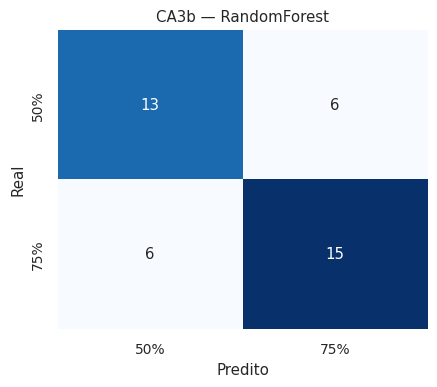

  Salvo: matriz_confusao_ca3b_randomforest.png


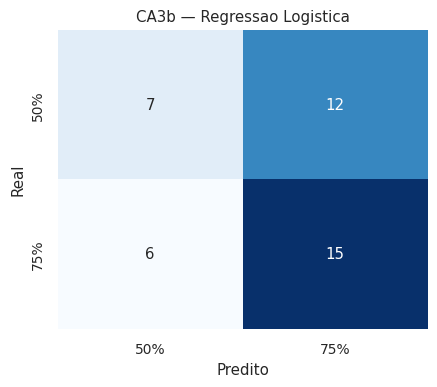

  Salvo: matriz_confusao_ca3b_regressao_logistica.png


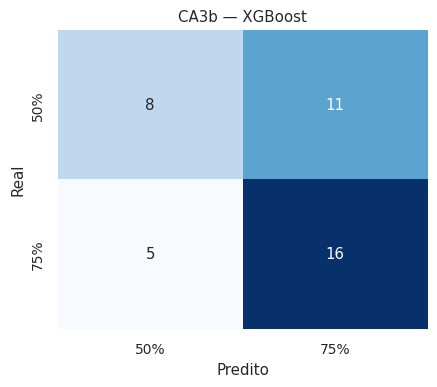

  Salvo: matriz_confusao_ca3b_xgboost.png


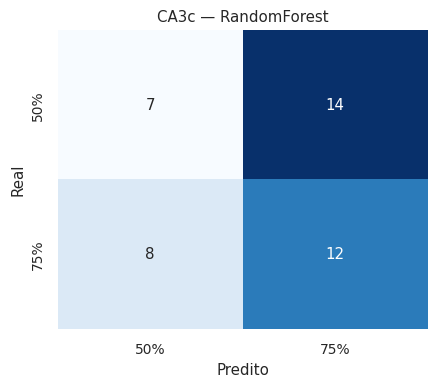

  Salvo: matriz_confusao_ca3c_randomforest.png


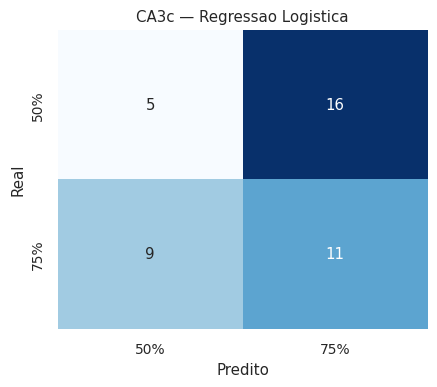

  Salvo: matriz_confusao_ca3c_regressao_logistica.png


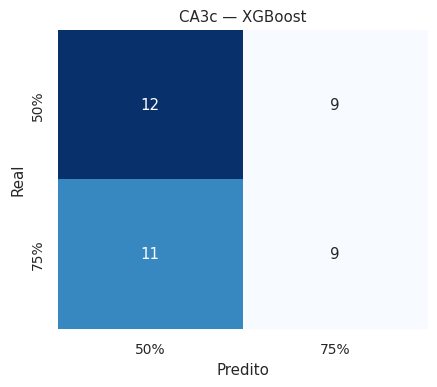

  Salvo: matriz_confusao_ca3c_xgboost.png


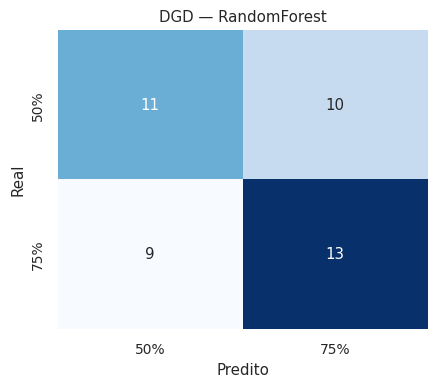

  Salvo: matriz_confusao_dgd_randomforest.png


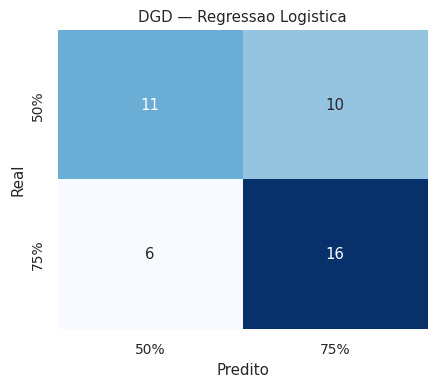

  Salvo: matriz_confusao_dgd_regressao_logistica.png


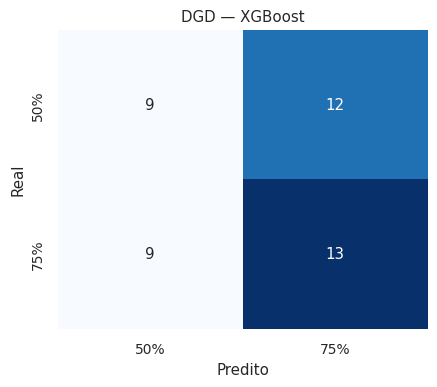

  Salvo: matriz_confusao_dgd_xgboost.png


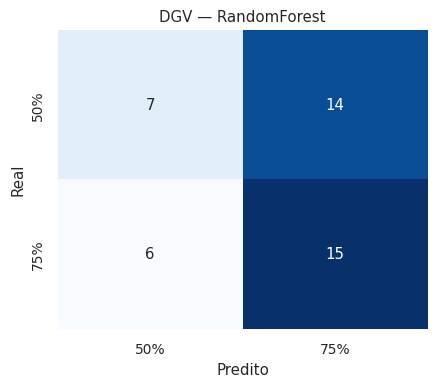

  Salvo: matriz_confusao_dgv_randomforest.png


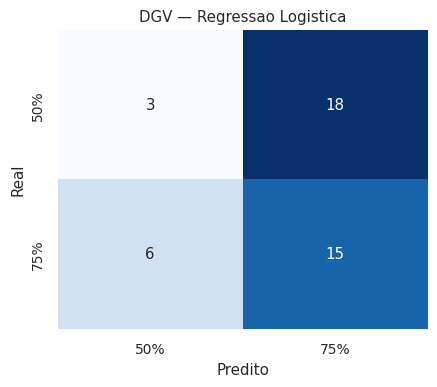

  Salvo: matriz_confusao_dgv_regressao_logistica.png


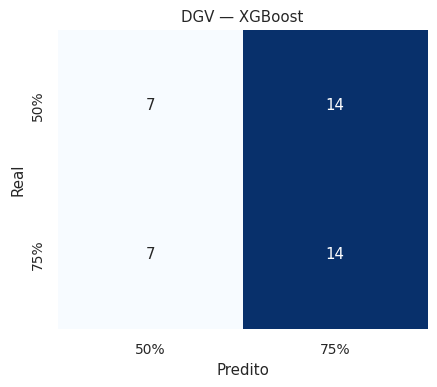

  Salvo: matriz_confusao_dgv_xgboost.png

Matrizes de confusao salvas.


In [ ]:
print("\n" + "=" * 70)
print("Salvando matrizes de confusao (uma por area x modelo)")
print("=" * 70)

for area in AREAS:
    for nome_modelo, resultado in resultados_por_area.get(area, {}).items():
        cm = resultado["matriz_confusao"]
        labels_cm = resultado["labels"]

        fig, ax = plt.subplots(figsize=(4.5, 4))
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_cm, yticklabels=labels_cm,
            cbar=False, ax=ax,
        )
        ax.set_xlabel("Predito")
        ax.set_ylabel("Real")
        ax.set_title(f"{area} \u2014 {nome_modelo}")
        plt.tight_layout()

        nome_arquivo = f"{area}_{nome_modelo}".lower().replace(" ", "_")
        caminho_fig = pasta_resultados / f"matriz_confusao_{nome_arquivo}.png"
        fig.savefig(caminho_fig, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close(fig)
        print(f"  Salvo: {caminho_fig.name}")

print("\nMatrizes de confusao salvas.")


## 6. Teste de Permutação por Área (com correção de Bonferroni)

Testa, para cada área, o modelo com maior `balanced_accuracy` observada -- mesma
simplificação pragmática das versões anteriores (config fixa por fold, rótulos
embaralhados por trial).

**Correção de Bonferroni:** como são **4 testes independentes** (1 por área), o
limiar de significância usual (`α = 0.05`) fica `α_corrigido = 0.05 / 4 = 0.0125`.
Uma área só deve ser chamada de "significativa" se `p < 0.0125`, não `p < 0.05` --
caso contrário, a chance de algum p vir baixo só por acaso (entre os 4 testes) fica
bem mais alta do que 5%.

In [ ]:
def teste_permutacao_area(df_long_limpo, area, resultado, estimator, y_transformer=None,
                          n_permutacoes=50, random_state=RANDOM_STATE, rotulo="modelo"):
    rng = np.random.RandomState(random_state)
    y_transformer = y_transformer or (lambda y: y)
    df_configs = resultado["df_configs_por_fold"].set_index("rato_teste")
    bal_acc_observado = resultado["df_resultados"]["balanced_accuracy"].mean()
    ratos = resultado["df_resultados"]["rato_teste"].tolist()

    bal_acc_nulo = []
    for p in range(n_permutacoes):
        mapa_stem = df_long_limpo.drop_duplicates("stem")[["stem", "condicao"]].copy()
        mapa_stem["condicao_perm"] = rng.permutation(mapa_stem["condicao"].values)
        df_perm = df_long_limpo.merge(mapa_stem[["stem", "condicao_perm"]], on="stem", how="left")
        df_perm = df_perm.drop(columns=["condicao"]).rename(columns={"condicao_perm": "condicao"})

        bal_accs_fold = []
        for rato_teste in ratos:
            cfg = df_configs.loc[rato_teste]
            df_treino_long = df_perm[df_perm["rato"] != rato_teste]
            df_teste_long = df_perm[df_perm["rato"] == rato_teste]
            saida = montar_dataset_treino_teste_area(df_treino_long, df_teste_long, area, cfg["n_bins"])
            if saida[0] is None:
                continue
            X_tr, y_tr, _, X_te, y_te, _ = saida
            y_tr = y_transformer((y_tr * 100).round().astype(int))
            y_te = y_transformer((y_te * 100).round().astype(int))
            pipe = montar_pipeline(clone(estimator), cfg["usa_selecao"])
            pipe.set_params(**cfg["params"])
            pipe.fit(X_tr, y_tr)
            y_pred = pipe.predict(X_te)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", category=UserWarning)
                bal_accs_fold.append(balanced_accuracy_score(y_te, y_pred))
        if bal_accs_fold:
            bal_acc_nulo.append(np.mean(bal_accs_fold))

    bal_acc_nulo = np.array(bal_acc_nulo)
    p_valor = (np.sum(bal_acc_nulo >= bal_acc_observado) + 1) / (len(bal_acc_nulo) + 1)

    print(f"[{rotulo}] observado={bal_acc_observado:.3f} | nulo={bal_acc_nulo.mean():.3f}+/-{bal_acc_nulo.std():.3f} "
          f"| p={p_valor:.4f}")

    return {"bal_acc_observado": bal_acc_observado, "bal_acc_nulo": bal_acc_nulo, "p_valor": p_valor}


ALPHA_NOMINAL = 0.05
ALPHA_BONFERRONI = ALPHA_NOMINAL / len(AREAS)
print(f"Limiar de significancia nominal: {ALPHA_NOMINAL} | corrigido (Bonferroni, {len(AREAS)} areas): {ALPHA_BONFERRONI:.4f}")

resumo_permutacao = []
for area in AREAS:
    if not resultados_por_area.get(area):
        continue
    melhor_modelo_area = max(
        resultados_por_area[area].items(),
        key=lambda kv: kv[1]["df_resultados"]["balanced_accuracy"].mean(),
    )
    nome_modelo, resultado = melhor_modelo_area
    y_transformer_area = codificar_y_xgb if nome_modelo == "XGBoost" else (lambda y: y)
    estimator_area = estimadores_base[area][nome_modelo]

    print(f"\n--- {area}: testando {nome_modelo} (melhor da area) ---")
    perm = teste_permutacao_area(
        df_limpo, area, resultado, clone(estimator_area), y_transformer=y_transformer_area,
        n_permutacoes=50, rotulo=f"{area}/{nome_modelo}",
    )
    resumo_permutacao.append({
        "area": area, "melhor_modelo": nome_modelo,
        "balanced_accuracy": perm["bal_acc_observado"], "p_valor": perm["p_valor"],
        "significativo_bonferroni": perm["p_valor"] < ALPHA_BONFERRONI,
    })

df_permutacao = pd.DataFrame(resumo_permutacao)
print("\n=== Resumo do teste de permutacao por area (com correcao de Bonferroni) ===")
display(df_permutacao)


Limiar de significancia nominal: 0.05 | corrigido (Bonferroni, 4 areas): 0.0125

--- CA3b: testando RandomForest (melhor da area) ---
[CA3b/RandomForest] observado=0.690 | nulo=0.477+/-0.112 | p=0.0588

--- CA3c: testando XGBoost (melhor da area) ---
[CA3c/XGBoost] observado=0.548 | nulo=0.514+/-0.082 | p=0.2745

--- DGD: testando Regressao Logistica (melhor da area) ---
[DGD/Regressao Logistica] observado=0.613 | nulo=0.504+/-0.093 | p=0.1373

--- DGV: testando XGBoost (melhor da area) ---
[DGV/XGBoost] observado=0.494 | nulo=0.499+/-0.088 | p=0.5686

=== Resumo do teste de permutacao por area (com correcao de Bonferroni) ===


,area,melhor_modelo,balanced_accuracy,p_valor,significativo_bonferroni
0,CA3b,RandomForest,0.690476,0.058824,False
1,CA3c,XGBoost,0.547619,0.274510,False
2,DGD,Regressao Logistica,0.613095,0.137255,False
3,DGV,XGBoost,0.494048,0.568627,False


## 7. Comparação Final entre Áreas e Exportação dos Resultados

=== Comparacao final -- balanced_accuracy por area x modelo ===


,area,modelo,balanced_accuracy_media,balanced_accuracy_dp,f1_macro_media,n_folds,n_trials_medio_por_fold
0,CA3b,RandomForest,0.690,0.342,0.609,7,5.714
2,CA3b,XGBoost,0.655,0.219,0.538,7,5.714
1,CA3b,Regressao Logistica,0.571,0.352,0.460,7,5.714
5,CA3c,XGBoost,0.548,0.169,0.457,7,5.857
4,CA3c,Regressao Logistica,0.452,0.216,0.351,7,5.857
3,CA3c,RandomForest,0.440,0.240,0.374,7,5.857
7,DGD,Regressao Logistica,0.613,0.266,0.509,7,6.143
6,DGD,RandomForest,0.506,0.297,0.412,7,6.143
8,DGD,XGBoost,0.464,0.296,0.399,7,6.143
11,DGV,XGBoost,0.494,0.174,0.405,7,6.000


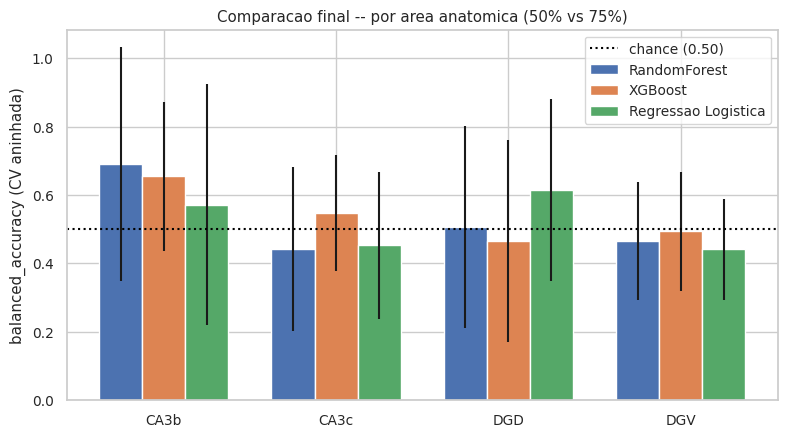


Resultados salvos em: /content/resultados_por_area_v4

Lembrete: so chame uma area de 'significativa' se p < 0.0125 (Bonferroni), nao p < 0.05.


In [ ]:
linhas_comparacao = []
for area in AREAS:
    for nome_modelo, resultado in resultados_por_area.get(area, {}).items():
        df_r = resultado["df_resultados"]
        linhas_comparacao.append({
            "area": area, "modelo": nome_modelo,
            "balanced_accuracy_media": df_r["balanced_accuracy"].mean(),
            "balanced_accuracy_dp": df_r["balanced_accuracy"].std(),
            "f1_macro_media": df_r["f1_macro"].mean(),
            "n_folds": len(df_r),
            "n_trials_medio_por_fold": df_r["n_trials_teste"].mean(),
        })

df_comparacao = pd.DataFrame(linhas_comparacao).sort_values(
    ["area", "balanced_accuracy_media"], ascending=[True, False]
)
print("=== Comparacao final -- balanced_accuracy por area x modelo ===")
display(df_comparacao.round(3))

chance_nivel = 1 / len(CONDICOES_ALVO)
fig, ax = plt.subplots(figsize=(8, 4.5))
largura = 0.25
posicoes_area = {area: idx for idx, area in enumerate(AREAS)}
modelos_unicos = df_comparacao["modelo"].unique()
for j, modelo in enumerate(modelos_unicos):
    sub = df_comparacao[df_comparacao["modelo"] == modelo]
    xs = [posicoes_area[a] + j * largura for a in sub["area"]]
    ax.bar(xs, sub["balanced_accuracy_media"], width=largura,
           yerr=sub["balanced_accuracy_dp"], label=modelo)
ax.axhline(chance_nivel, color="black", linestyle=":", label=f"chance ({chance_nivel:.2f})")
ax.set_xticks([v + largura for v in posicoes_area.values()])
ax.set_xticklabels(AREAS)
ax.set_ylabel("balanced_accuracy (CV aninhada)")
ax.set_title("Comparacao final -- por area anatomica (50% vs 75%)")
ax.legend()
plt.tight_layout()
plt.show()

df_comparacao.to_csv(pasta_resultados / "comparacao_final_por_area.csv", index=False)
df_permutacao.to_csv(pasta_resultados / "teste_permutacao_por_area.csv", index=False)

for area in AREAS:
    for nome_modelo, resultado in resultados_por_area.get(area, {}).items():
        nome_arquivo = f"{area}_{nome_modelo}".lower().replace(" ", "_")
        resultado["df_resultados"].to_csv(
            pasta_resultados / f"resultados_por_fold_{nome_arquivo}.csv", index=False
        )

print(f"\nResultados salvos em: {pasta_resultados.resolve()}")
print(f"\nLembrete: so chame uma area de 'significativa' se p < {ALPHA_BONFERRONI:.4f} (Bonferroni), nao p < 0.05.")


## 8. Interpretação com SHAP — modelo final por área

Para cada área, treina um **modelo final** (com todos os trials daquela área,
sem CV) usando o tipo de modelo que teve a melhor `balanced_accuracy` na Seção 5,
e a configuração (n_bins / seleção de atributos / hiperparâmetros) mais frequente
entre os folds da CV aninhada. Esse modelo final é usado **só para interpretação**
(SHAP) -- as métricas reportadas continuam sendo as da CV aninhada (Seção 5) e do
teste de permutação (Seção 6), não deste modelo final.

Para cada área salva: gráfico `summary_plot` do SHAP (PNG) e um CSV com a
importância média (|SHAP|) de cada atributo.



Interpretacao SHAP -- modelo final por area (melhor modelo de cada area)

--- CA3b: modelo final = RandomForest | config = {'n_bins': 2, 'usa_selecao': False, 'params': {'clf__class_weight': 'balanced', 'clf__max_depth': 3, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 3, 'clf__n_estimators': 100}} ---


<Figure size 640x480 with 0 Axes>

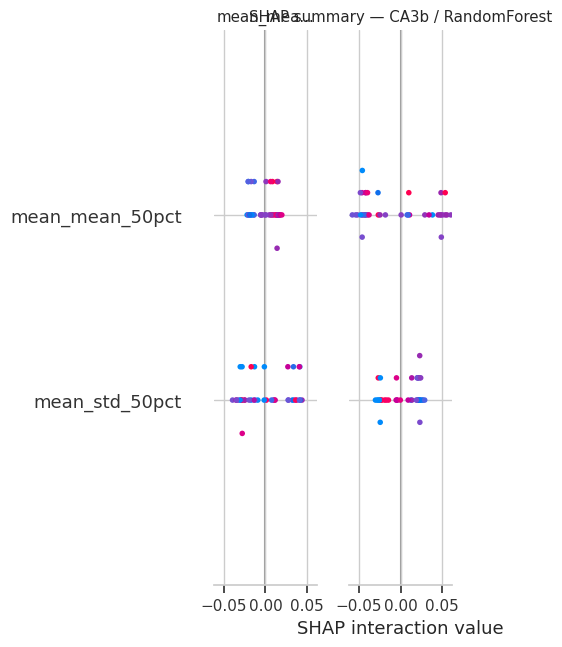

  Salvo: shap_summary_ca3b_randomforest.png

--- CA3c: modelo final = XGBoost | config = {'n_bins': 8, 'usa_selecao': False, 'params': {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.03, 'clf__max_depth': 2, 'clf__n_estimators': 100, 'clf__subsample': 1.0}} ---


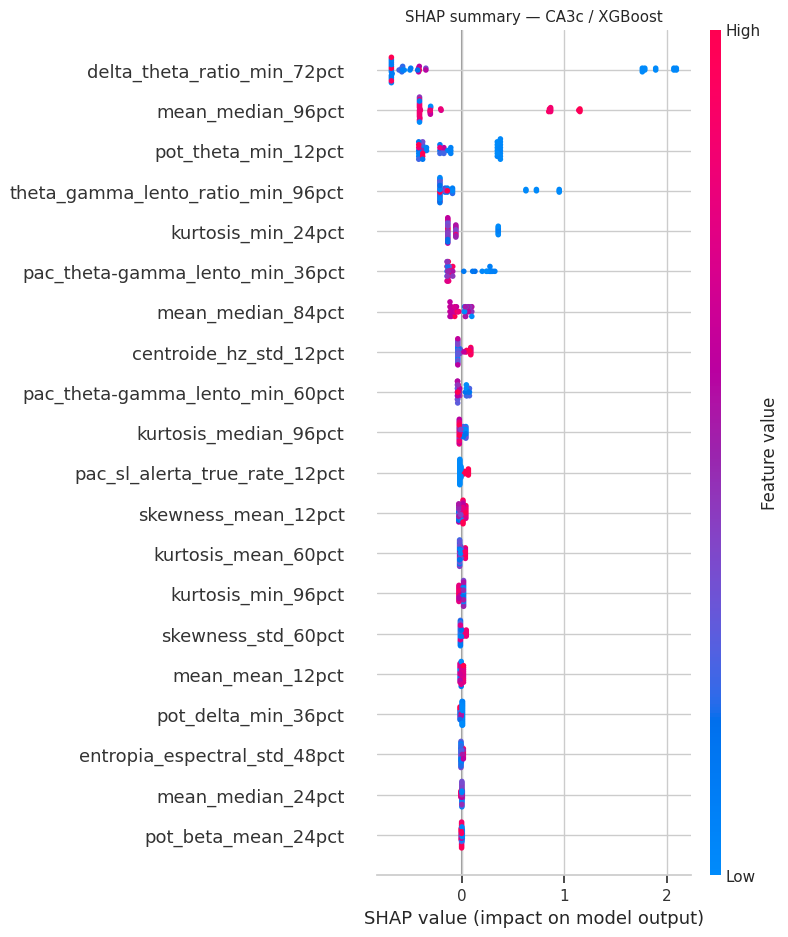

  Salvo: shap_summary_ca3c_xgboost.png

--- DGD: modelo final = Regressao Logistica | config = {'n_bins': 2, 'usa_selecao': True, 'params': {'clf__C': 100, 'clf__class_weight': None, 'clf__max_iter': 5000, 'clf__penalty': 'l1', 'clf__solver': 'liblinear', 'selector__max_features': 10}} ---


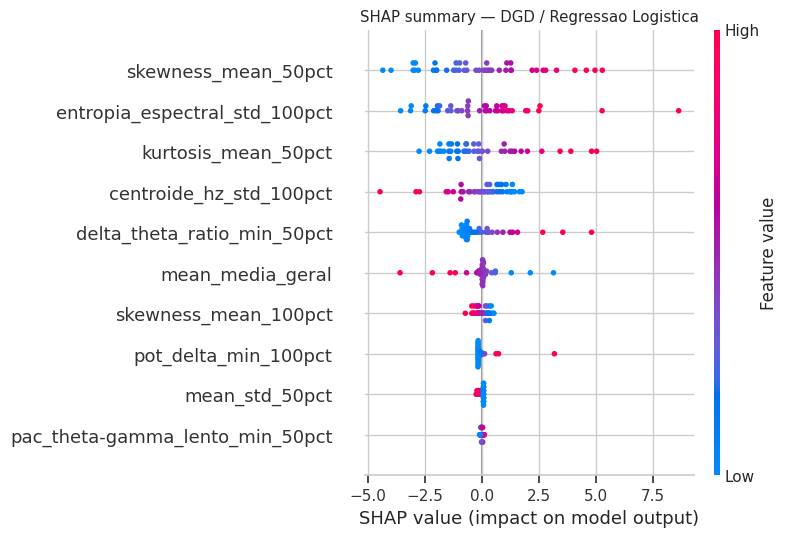

  Salvo: shap_summary_dgd_regressao_logistica.png

--- DGV: modelo final = XGBoost | config = {'n_bins': 5, 'usa_selecao': True, 'params': {'clf__colsample_bytree': 0.7, 'clf__learning_rate': 0.03, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 1.0, 'selector__max_features': 10}} ---


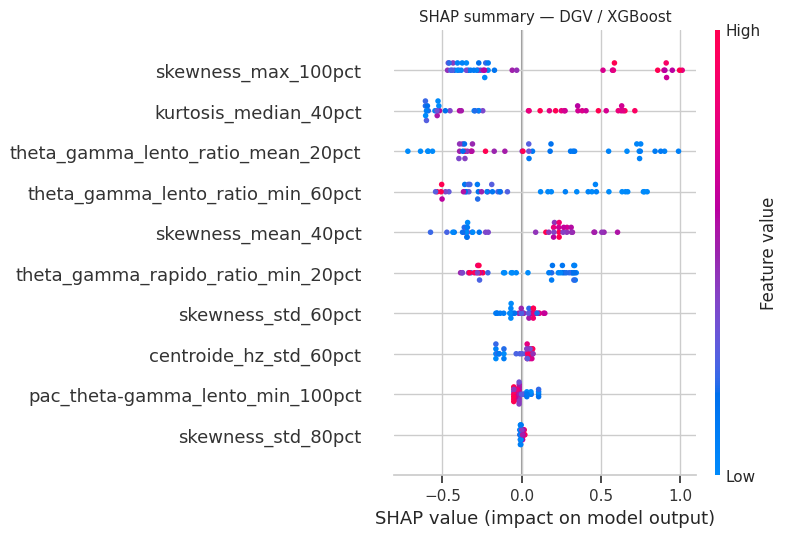

  Salvo: shap_summary_dgv_xgboost.png

Secao 8 concluida (SHAP salvo em resultados_por_area_v4/, quando disponivel).


In [ ]:
from collections import Counter

def _config_mais_frequente(df_configs):
    """Pega o n_bins/selecao mais frequentes entre os folds da CV aninhada e os
    params do fold que bate com essa moda -- so para montar um 'modelo final'
    unico para interpretacao (SHAP). Nao influencia nenhuma metrica ja
    reportada nas Secoes 5/6."""
    moda_n_bins = Counter(df_configs["n_bins"]).most_common(1)[0][0]
    df_moda = df_configs[df_configs["n_bins"] == moda_n_bins]
    moda_selecao = Counter(df_moda["usa_selecao"]).most_common(1)[0][0]
    df_moda = df_moda[df_moda["usa_selecao"] == moda_selecao]
    params = df_moda.iloc[0]["params"]
    return {"n_bins": moda_n_bins, "usa_selecao": moda_selecao, "params": params}


resultados_shap = {}

if not SHAP_DISPONIVEL:
    print("SHAP nao instalado -- pulei a Secao 8. Rode 'pip install shap' e reexecute.")
else:
    print("\n" + "=" * 70)
    print("Interpretacao SHAP -- modelo final por area (melhor modelo de cada area)")
    print("=" * 70)

    for area in AREAS:
        if not resultados_por_area.get(area):
            continue

        nome_modelo, resultado = max(
            resultados_por_area[area].items(),
            key=lambda kv: kv[1]["df_resultados"]["balanced_accuracy"].mean(),
        )
        config_final = _config_mais_frequente(resultado["df_configs_por_fold"])
        print(f"\n--- {area}: modelo final = {nome_modelo} | config = {config_final} ---")

        X_final, y_final, groups_final, stems_final, _ = montar_dataset_modelagem_area(
            df_limpo, area, config_final["n_bins"], verbose=False
        )
        if X_final is None:
            print(f"  [{area}] dados insuficientes para o modelo final -- pulando SHAP.")
            continue

        y_transformer_area = codificar_y_xgb if nome_modelo == "XGBoost" else (lambda y: y)
        y_final_cod = y_transformer_area((y_final * 100).round().astype(int))

        estimator_area = estimadores_base[area][nome_modelo]
        pipe_final = montar_pipeline(clone(estimator_area), config_final["usa_selecao"])
        pipe_final.set_params(**config_final["params"])
        pipe_final.fit(X_final, y_final_cod)

        # Dados no espaco de entrada do classificador (pos scaler + selecao de
        # atributos) -- e nesse espaco que o SHAP explica as previsoes.
        X_transformado = pipe_final[:-1].transform(X_final)
        if "selector" in pipe_final.named_steps:
            colunas_shap = X_final.columns[pipe_final.named_steps["selector"].get_support()]
        else:
            colunas_shap = X_final.columns
        X_transformado_df = pd.DataFrame(X_transformado, columns=colunas_shap)

        clf_final = pipe_final.named_steps["clf"]

        try:
            if nome_modelo in ("RandomForest", "XGBoost"):
                explainer = shap.TreeExplainer(clf_final)
            else:
                explainer = shap.LinearExplainer(clf_final, X_transformado_df)
            valores_shap = explainer(X_transformado_df)
        except Exception as exc:
            print(f"  [{area}] falha ao calcular SHAP ({exc}) -- pulando.")
            continue

        resultados_shap[area] = {
            "nome_modelo": nome_modelo, "config": config_final,
            "valores_shap": valores_shap, "X": X_transformado_df,
        }

        nome_arquivo = f"{area}_{nome_modelo}".lower().replace(" ", "_")

        # Summary plot (beeswarm).
        plt.figure()
        try:
            shap.summary_plot(valores_shap, X_transformado_df, show=False)
        except Exception:
            valores_plot = valores_shap.values if hasattr(valores_shap, "values") else valores_shap
            shap.summary_plot(valores_plot, X_transformado_df, show=False)
        plt.title(f"SHAP summary \u2014 {area} / {nome_modelo}")
        plt.tight_layout()
        caminho_shap = pasta_resultados / f"shap_summary_{nome_arquivo}.png"
        plt.savefig(caminho_shap, dpi=150, bbox_inches="tight")
        plt.show()
        plt.close()
        print(f"  Salvo: {caminho_shap.name}")

        # Importancia media |SHAP| por atributo, em CSV (complementa o grafico).
        valores_array = valores_shap.values if hasattr(valores_shap, "values") else np.array(valores_shap)
        if valores_array.ndim == 3:  # (n_amostras, n_features, n_classes)
            importancia = np.abs(valores_array).mean(axis=(0, 2))
        else:
            importancia = np.abs(valores_array).mean(axis=0)
        df_importancia = pd.DataFrame({
            "feature": colunas_shap, "shap_importancia_media_abs": importancia,
        }).sort_values("shap_importancia_media_abs", ascending=False)
        df_importancia.to_csv(pasta_resultados / f"shap_importancia_{nome_arquivo}.csv", index=False)

    print("\nSecao 8 concluida (SHAP salvo em resultados_por_area_v4/, quando disponivel).")


In [ ]:
import shutil
import os

output_filename = '/content/resultados_por_area_v4'
shutil.make_archive(output_filename, 'zip', output_filename)
print(f"Directory compressed to {output_filename}.zip")

Directory compressed to /content/resultados_por_area_v4.zip


## 9. Checklist de Análise dos Modelos (desempenho, erros, ratos, regiões, literatura)

Esta seção consome o que já foi calculado nas Seções 5-8 (`resultados_por_area`,
`resultados_shap`) e responde, de forma sistemática, ao checklist de análise:
desempenho geral, matriz de confusão, erros/acertos por classe, por rato, por
feature/região, o cruzamento rato × região sugerido pela orientadora, a
comparação entre modelos e, por fim, uma comparação com a literatura (tese e
artigos do projeto).

> Pré-requisito: rode as Seções 1-8 antes desta (ela depende de
> `resultados_por_area`, `estimadores_base` e, se disponível, `resultados_shap`).
> A Seção 5 (função `treinar_avaliar_aninhado_area`, Seção 4) foi ajustada para
> também guardar `df_predicoes` -- as predições trial a trial (rato, stem,
> y_true, y_pred) -- então **reexecute as Seções 4 e 5** antes de rodar esta
> Seção 9 se você já tinha rodado uma versão antiga do notebook.

### 9.0 Consolidar as predições trial a trial de todos os modelos/áreas

In [ ]:
# Empilha o df_predicoes de cada (area, modelo) num unico DataFrame -- essa
# tabela e a base de quase todo o resto da Secao 9.
lista_predicoes = []
for area in AREAS:
    for nome_modelo, resultado in resultados_por_area.get(area, {}).items():
        df_pred = resultado.get("df_predicoes")
        if df_pred is not None and not df_pred.empty:
            lista_predicoes.append(df_pred)

if not lista_predicoes:
    raise RuntimeError(
        "Nenhum df_predicoes encontrado em resultados_por_area -- reexecute as "
        "Secoes 4 e 5 (elas foram atualizadas para gerar predicoes trial a trial)."
    )

df_predicoes_geral = pd.concat(lista_predicoes, ignore_index=True)
df_predicoes_geral["y_true"] = df_predicoes_geral["y_true"].astype(int)
df_predicoes_geral["y_pred"] = df_predicoes_geral["y_pred"].astype(int)

print(f"Total de predicoes trial a trial: {len(df_predicoes_geral)}")
display(df_predicoes_geral.head())
df_predicoes_geral.to_csv(pasta_resultados / "predicoes_trial_a_trial.csv", index=False)

### 9.1 Desempenho geral (acurácia, precisão, recall, F1, AUC)

`balanced_accuracy` e `f1_macro` já são reportados por fold nas Seções 5-7
(`df_resultados`). Aqui agregamos **acurácia simples, precisão, recall e F1**
por área × modelo, a partir das predições trial a trial (`df_predicoes_geral`).

> **AUC**: o pipeline atual chama `pipe.predict(...)`, não `predict_proba`, então
> não há probabilidades salvas para calcular AUC sem re-treinar. Se você quiser
> AUC, o jeito mais simples é adaptar a Seção 5 para também guardar
> `pipe.predict_proba(X_te)[:, 1]` por fold -- deixado como próximo passo, não
> incluído aqui para não exigir re-rodar toda a CV aninhada.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score as f1_score_fn

linhas_desempenho = []
for (area, modelo), grupo in df_predicoes_geral.groupby(["area", "modelo"]):
    y_true_g, y_pred_g = grupo["y_true"], grupo["y_pred"]
    linhas_desempenho.append({
        "area": area, "modelo": modelo, "n_trials": len(grupo),
        "acuracia": accuracy_score(y_true_g, y_pred_g),
        "precisao_75": precision_score(y_true_g, y_pred_g, pos_label=75, zero_division=0),
        "recall_75": recall_score(y_true_g, y_pred_g, pos_label=75, zero_division=0),
        "f1_75": f1_score_fn(y_true_g, y_pred_g, pos_label=75, zero_division=0),
        "precisao_50": precision_score(y_true_g, y_pred_g, pos_label=50, zero_division=0),
        "recall_50": recall_score(y_true_g, y_pred_g, pos_label=50, zero_division=0),
        "f1_50": f1_score_fn(y_true_g, y_pred_g, pos_label=50, zero_division=0),
    })

df_desempenho_geral = pd.DataFrame(linhas_desempenho).sort_values(
    ["area", "acuracia"], ascending=[True, False]
)
print("=== 9.1 Desempenho geral por area x modelo (a partir das predicoes trial a trial) ===")
display(df_desempenho_geral.round(3))
df_desempenho_geral.to_csv(pasta_resultados / "desempenho_geral_secao9.csv", index=False)

### 9.2 Matriz de confusão — classes com maior acerto e classes mais confundidas

As figuras da matriz de confusão já foram salvas na Seção 5b. Aqui extraímos,
de cada matriz (`resultado["matriz_confusao"]`), qual classe (50% ou 75%) tem
maior taxa de acerto (recall da própria classe) e o quanto as duas classes se
confundem entre si.

In [ ]:
linhas_cm = []
for area in AREAS:
    for nome_modelo, resultado in resultados_por_area.get(area, {}).items():
        cm = resultado["matriz_confusao"]
        labels_cm = resultado["labels"]
        if cm.shape != (2, 2):
            continue
        recall_classe0 = cm[0, 0] / cm[0].sum() if cm[0].sum() else np.nan
        recall_classe1 = cm[1, 1] / cm[1].sum() if cm[1].sum() else np.nan
        linhas_cm.append({
            "area": area, "modelo": nome_modelo,
            f"recall_{labels_cm[0]}": recall_classe0,
            f"recall_{labels_cm[1]}": recall_classe1,
            "classe_mais_acertada": labels_cm[0] if recall_classe0 >= recall_classe1 else labels_cm[1],
            "classe_mais_confundida": labels_cm[0] if recall_classe0 < recall_classe1 else labels_cm[1],
            "diferenca_recall": abs(recall_classe0 - recall_classe1),
        })

df_cm_resumo = pd.DataFrame(linhas_cm).sort_values("diferenca_recall", ascending=False)
print("=== 9.2 Recall por classe (50% vs 75%), area x modelo ===")
display(df_cm_resumo.round(3))
print("\nClasse mais acertada em geral:")
print(df_cm_resumo["classe_mais_acertada"].value_counts())

### 9.3-9.4 Análise dos erros e dos acertos

Quais classes concentram mais erro, se o padrão de erro se repete entre
modelos, e exemplos concretos de trials classificados incorretamente
(rato, stem, área, modelo, real x predito).

In [ ]:
df_predicoes_geral["erro"] = ~df_predicoes_geral["acertou"]

print("=== 9.3 Taxa de erro por classe real (todas as areas/modelos juntos) ===")
display(df_predicoes_geral.groupby("y_true")["erro"].mean().round(3).rename("taxa_erro"))

print("\n=== 9.3 Taxa de erro por area (todas as classes/modelos juntos) ===")
display(df_predicoes_geral.groupby("area")["erro"].mean().sort_values(ascending=False).round(3).rename("taxa_erro"))

print("\n=== 9.3 Erros que se repetem no MESMO stem em mais de um modelo ===")
erros_por_stem_modelo = (
    df_predicoes_geral[df_predicoes_geral["erro"]]
    .groupby(["area", "stem"])["modelo"].nunique()
    .sort_values(ascending=False)
)
stems_erro_recorrente = erros_por_stem_modelo[erros_por_stem_modelo > 1]
display(stems_erro_recorrente.rename("n_modelos_que_erraram").to_frame())

print("\n=== 9.4 Exemplos de classificacoes incorretas (amostra) ===")
display(
    df_predicoes_geral[df_predicoes_geral["erro"]]
    [["area", "modelo", "rato", "stem", "y_true", "y_pred"]]
    .sort_values(["area", "modelo", "rato"])
    .head(30)
)

print("\n=== 9.4 Acertos: taxa de acerto por classe e por area ===")
display(df_predicoes_geral.groupby("y_true")["acertou"].mean().round(3).rename("taxa_acerto"))
display(df_predicoes_geral.groupby("area")["acertou"].mean().sort_values(ascending=False).round(3).rename("taxa_acerto"))

### 9.5 Análise por rato

Para cada rato: número de amostras, taxa de acerto/erro (geral e por modelo),
e uma sinalização de quando ele fica **mais de 1 desvio-padrão abaixo da média
dos demais ratos** -- candidato a "rato problemático". Também verificamos se o
mesmo rato aparece como problemático em mais de um modelo (RF, LogReg, XGB).

In [ ]:
resumo_rato = (
    df_predicoes_geral.groupby(["rato", "modelo"])
    .agg(n_amostras=("acertou", "size"), taxa_acerto=("acertou", "mean"))
    .reset_index()
)
resumo_rato["taxa_erro"] = 1 - resumo_rato["taxa_acerto"]

print("=== 9.5 Taxa de acerto por rato x modelo ===")
display(resumo_rato.sort_values(["modelo", "taxa_acerto"]).round(3))

# Media/DP da taxa de acerto entre ratos, por modelo -- para flagar outliers.
linhas_flag = []
for modelo, sub in resumo_rato.groupby("modelo"):
    media, dp = sub["taxa_acerto"].mean(), sub["taxa_acerto"].std()
    limiar = media - dp
    for _, row in sub.iterrows():
        linhas_flag.append({
            "modelo": modelo, "rato": row["rato"], "n_amostras": row["n_amostras"],
            "taxa_acerto": row["taxa_acerto"], "media_ratos": media, "limiar_1dp_abaixo": limiar,
            "abaixo_da_media_1dp": row["taxa_acerto"] < limiar,
        })
df_flag_rato = pd.DataFrame(linhas_flag)

print("\n=== 9.5 Ratos > 1 desvio-padrao ABAIXO da media dos demais (por modelo) ===")
display(df_flag_rato[df_flag_rato["abaixo_da_media_1dp"]].sort_values(["rato", "modelo"]).round(3))

print("\n=== 9.5 Ratos problematicos em MAIS DE UM modelo (candidato mais forte a 'rato problematico') ===")
contagem_modelos_problema = (
    df_flag_rato[df_flag_rato["abaixo_da_media_1dp"]]
    .groupby("rato")["modelo"].nunique().sort_values(ascending=False)
)
display(contagem_modelos_problema.rename("n_modelos_em_que_e_outlier").to_frame())

# Grafico: taxa de acerto por rato, uma barra por modelo.
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=resumo_rato, x="rato", y="taxa_acerto", hue="modelo", ax=ax)
ax.axhline(0.5, color="black", linestyle=":", label="chance (50%)")
ax.set_ylabel("Taxa de acerto (todas as areas juntas)")
ax.set_title("9.5 -- Taxa de acerto por rato x modelo")
plt.tight_layout()
plt.savefig(pasta_resultados / "secao9_taxa_acerto_por_rato.png", dpi=150, bbox_inches="tight")
plt.show()

resumo_rato.to_csv(pasta_resultados / "secao9_resumo_por_rato.csv", index=False)

### 9.6 Análise por feature / região cerebral

Duas fontes de informação:

1. **Importância SHAP** (Seção 8, `resultados_shap`) -- quais *features* o
   modelo final de cada área mais usa.
2. **Desempenho por área** (`df_desempenho_geral`, 9.1) -- qual *região
   cerebral* (CA3b, CA3c, DGD, DGV) rende mais/menos acerto, um proxy de
   "quanto sinal essa área carrega" para a tarefa 50% vs 75%.

Combinamos as duas para responder: existe uma região que **consistentemente
piora** a classificação, e uma que **consistentemente melhora**?

In [ ]:
if "resultados_shap" in globals() and resultados_shap:
    print("=== 9.6 Top 10 features (SHAP) por area (modelo final de cada area) ===")
    linhas_top_shap = []
    for area, info_shap in resultados_shap.items():
        valores_shap = info_shap["valores_shap"]
        X_shap = info_shap["X"]
        valores_array = valores_shap.values if hasattr(valores_shap, "values") else np.array(valores_shap)
        importancia = (np.abs(valores_array).mean(axis=(0, 2)) if valores_array.ndim == 3
                       else np.abs(valores_array).mean(axis=0))
        df_imp = pd.DataFrame({"feature": X_shap.columns, "importancia": importancia})
        df_imp = df_imp.sort_values("importancia", ascending=False).head(10)
        df_imp.insert(0, "area", area)
        df_imp.insert(1, "modelo", info_shap["nome_modelo"])
        linhas_top_shap.append(df_imp)
    df_top_shap_geral = pd.concat(linhas_top_shap, ignore_index=True)
    display(df_top_shap_geral.round(4))
    df_top_shap_geral.to_csv(pasta_resultados / "secao9_top10_features_shap_por_area.csv", index=False)

    print("\n=== 9.6 Features que aparecem no top-10 de MAIS DE UMA area (possivel padrao cross-area) ===")
    contagem_area_por_feature = df_top_shap_geral.groupby("feature")["area"].nunique().sort_values(ascending=False)
    display(contagem_area_por_feature[contagem_area_por_feature > 1].rename("n_areas").to_frame())
else:
    print("resultados_shap vazio/nao disponivel -- rode a Secao 8 (SHAP) antes desta celula.")

print("\n=== 9.6 Ranking de regioes (areas) por desempenho medio (acuracia media entre os 3 modelos) ===")
ranking_area = (
    df_desempenho_geral.groupby("area")["acuracia"].mean().sort_values(ascending=False)
)
display(ranking_area.round(3).rename("acuracia_media_entre_modelos"))
print("\nRegiao(oes) com MELHOR desempenho medio:", list(ranking_area.head(1).index))
print("Regiao(oes) com PIOR desempenho medio   :", list(ranking_area.tail(1).index))

### 9.7 Cruzamento rato × região cerebral

Esta é a análise sugerida pela orientadora: uma tabela rato × área com a taxa
de erro em cada combinação, para responder:

- Qual rato tem mais erros, e em qual região ele mais erra?
- Esse problema é exclusivo daquele rato ou aparece em vários?
- Existe uma região problemática **independente do rato** (erro alto na coluna
  inteira) ou o problema é específico de rato × região (uma célula isolada)?

In [ ]:
tabela_rato_area = (
    df_predicoes_geral.groupby(["rato", "area"])["erro"].mean().unstack("area")
)
print("=== 9.7 Taxa de erro por rato x area (todas os modelos juntos) ===")
display(tabela_rato_area.round(3))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(tabela_rato_area, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, ax=ax)
ax.set_title("9.7 -- Taxa de erro: rato x area")
plt.tight_layout()
plt.savefig(pasta_resultados / "secao9_heatmap_rato_x_area.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nRato com maior taxa de erro media (todas as areas):")
print(tabela_rato_area.mean(axis=1).sort_values(ascending=False).round(3))

print("\nPara o rato com pior media, a area onde ele MAIS erra:")
pior_rato = tabela_rato_area.mean(axis=1).idxmax()
print(f"  Rato: {pior_rato}")
print(tabela_rato_area.loc[pior_rato].sort_values(ascending=False).round(3))

print("\nArea com maior taxa de erro media (todos os ratos) -- candidata a 'regiao dificil "
      "independente do rato':")
print(tabela_rato_area.mean(axis=0).sort_values(ascending=False).round(3))

# Um problema e' "do rato" (varios ratos erram numa mesma area) ou "da celula"
# (so aquele rato-area especifico)? Compara desvio de cada celula em relacao
# a media da SUA coluna (area) e da SUA linha (rato).
media_por_area = tabela_rato_area.mean(axis=0)
media_por_rato = tabela_rato_area.mean(axis=1)
desvio_area = tabela_rato_area.sub(media_por_area, axis=1)   # >0: essa area, nesse rato, erra mais que a media da area
desvio_rato = tabela_rato_area.sub(media_por_rato, axis=0)   # >0: esse rato, nessa area, erra mais que a media do rato
print("\nCelulas rato x area que se destacam tanto acima da media da AREA quanto do RATO "
      "(erro concentrado, nao generalizado):")
destaque = (desvio_area > 0.15) & (desvio_rato > 0.15)
display(tabela_rato_area[destaque].dropna(how="all").round(3))

### 9.8 Comparação entre modelos

Qual modelo teve o melhor desempenho médio, se os modelos erram nas mesmas
classes/ratos (erro sistemático dos *dados*, não do algoritmo) e se usam as
mesmas features mais importantes.

In [ ]:
print("=== 9.8 Acuracia media por modelo (todas as areas juntas) ===")
display(df_desempenho_geral.groupby("modelo")["acuracia"].agg(["mean", "std"]).round(3))

print("\n=== 9.8 Melhor modelo por area (por acuracia media, 9.1) ===")
melhor_por_area = df_desempenho_geral.loc[df_desempenho_geral.groupby("area")["acuracia"].idxmax()]
display(melhor_por_area[["area", "modelo", "acuracia"]].round(3))

# Os modelos erram no MESMO trial (mesmo stem)? -- overlap de erro entre pares de modelo.
pivot_acerto = df_predicoes_geral.pivot_table(
    index=["area", "stem"], columns="modelo", values="acertou"
)
modelos_presentes = [c for c in pivot_acerto.columns]
print("\n=== 9.8 Sobreposicao de ERROS entre pares de modelo (Jaccard: erram no mesmo trial) ===")
for i in range(len(modelos_presentes)):
    for j in range(i + 1, len(modelos_presentes)):
        m1, m2 = modelos_presentes[i], modelos_presentes[j]
        sub = pivot_acerto[[m1, m2]].dropna()
        erro_m1 = ~sub[m1].astype(bool)
        erro_m2 = ~sub[m2].astype(bool)
        uniao = (erro_m1 | erro_m2).sum()
        intersecao = (erro_m1 & erro_m2).sum()
        jaccard = intersecao / uniao if uniao else np.nan
        print(f"  {m1} x {m2}: {intersecao} erros em comum / {uniao} erros totais (Jaccard={jaccard:.2f})")

if "df_top_shap_geral" in globals():
    print("\n=== 9.8 Overlap do top-10 SHAP entre modelos (quando modelos diferentes venceram em areas diferentes) ===")
    display(df_top_shap_geral.groupby(["area", "modelo"])["feature"].apply(list))

### 9.9 Comparação com a literatura

Preenchida a partir da tese de doutorado do projeto (Ana Paula de Castro
Araújo) e da literatura que ela revisa sobre o sistema DG-CA3. **Não é
gerada automaticamente pelos dados** -- é um roteiro para você confrontar com
os resultados das seções 9.1-9.7 depois de rodar o notebook.

**O que a literatura diz sobre DG e CA3:**
- O giro denteado (DG) é classicamente associado à **separação de padrões**
  (tornar entradas parecidas mais distintas), e a rede recorrente de CA3 ao
  **completamento de padrões** (reconstruir um padrão a partir de uma pista
  parcial) -- via trissináptica clássica DG → CA3 → CA1. Isso sugere que DG e
  CA3 podem carregar informação *complementar*, não redundante, sobre o quão
  parecidos dois estímulos são.
- A tese reporta que ao longo do eixo **rostro-caudal**, a expressão de c-Fos
  em CA3c rostral e no hilo rostral aumenta com a exigência de discriminação
  (tarefas com maior similaridade entre objetos), e que CA3c rostral se
  correlaciona fortemente com o desempenho comportamental (D2) especificamente
  na condição de **75%** de similaridade -- exatamente uma das duas condições
  classificadas aqui.
- CA3b rostral aparece envolvido no processo de discriminação, mas
  **só na condição de similaridade intermediária**.
- Em contraste, o **hipocampo medial** não mostrou diferenças de c-Fos entre
  condições de similaridade na tese -- ou seja, a literatura já aponta que nem
  toda subárea/nível anteroposterior carrega sinal para essa distinção.
- CA3b e CA3c (dorsais, como as áreas registradas neste dataset) fazem parte
  do sistema DG-CA3 dorsal, mais associado a discriminação e memória
  espacial/de objeto fina, enquanto DGV (giro denteado ventral) tende a se
  associar mais a processamento emocional/contextual em roedores.

**Perguntas para confrontar com os resultados das seções acima:**
- Os modelos treinados em **CA3c** e/ou **DGD** tiveram desempenho mais alto
  que os treinados em **DGV**? Isso seria compatível com o papel mais
  "discriminativo" atribuído a CA3/DG dorsal na tese.
- A classe **75%** (mais fácil de discriminar do objeto familiar, na lógica do
  NOR) teve recall mais alto que a classe **50%** (9.2)? Combina com a tese
  mostrar correlação mais forte de CA3c com desempenho justamente em 75%.
- Se **CA3b** aparece como a área mais fraca aqui, isso pode ser esperado --
  na tese, CA3b só mostra efeito na condição intermediária (que não está no
  escopo binário 50/75 deste notebook).
- Se surgir um padrão claramente diferente do esperado (ex.: DGV com
  desempenho mais alto que CA3c), vale registrar como um achado a discutir,
  não necessariamente um erro -- LFP/PAC captura uma dimensão de sinal
  diferente da expressão de c-Fos, então divergência é possível e interessante.

### 9.10 Resumo automático — respostas às perguntas centrais

Monta, a partir de tudo o que foi calculado acima, um resumo textual das
perguntas que o documento final deve responder. Rode por último, depois de
todas as células da Seção 9.

In [ ]:
print("=" * 78)
print("RESUMO AUTOMATICO -- Secao 9")
print("=" * 78)

# 1) Qual modelo foi o melhor?
media_modelo = df_desempenho_geral.groupby("modelo")["acuracia"].mean().sort_values(ascending=False)
print(f"\n1) Melhor modelo (acuracia media entre areas): {media_modelo.index[0]} "
      f"({media_modelo.iloc[0]:.3f})")
print(media_modelo.round(3))

# 2) Onde os modelos erram / 3) Onde acertam?
print(f"\n2-3) Classe com maior taxa de erro: "
      f"{df_predicoes_geral.groupby('y_true')['erro'].mean().idxmax()}%")
print(f"     Area com maior taxa de erro: "
      f"{df_predicoes_geral.groupby('area')['erro'].mean().idxmax()}")
print(f"     Area com maior taxa de acerto: "
      f"{df_predicoes_geral.groupby('area')['acertou'].mean().idxmax()}")

# 4) Existe padrao de erro?
print(f"\n4) Trials que erraram em mais de 1 modelo (padrao de erro nao ligado a "
      f"um algoritmo especifico): {len(stems_erro_recorrente)} trial(s) -- ver Secao 9.3.")

# 5) Rato(s) problematico(s)?
if len(contagem_modelos_problema) > 0:
    piores_ratos = contagem_modelos_problema[
        contagem_modelos_problema == contagem_modelos_problema.max()
    ].index.tolist()
    print(f"\n5) Rato(s) problematico(s) (outlier em mais modelos): {piores_ratos}")
else:
    print("\n5) Nenhum rato se destacou como outlier em mais de um modelo (ver 9.5).")

# 6) Em qual regiao esse rato problematico erra mais?
if len(contagem_modelos_problema) > 0:
    rato_alvo = piores_ratos[0]
    if rato_alvo in tabela_rato_area.index:
        area_pior = tabela_rato_area.loc[rato_alvo].idxmax()
        print(f"   Regiao onde {rato_alvo} mais erra: {area_pior} "
              f"(taxa de erro={tabela_rato_area.loc[rato_alvo, area_pior]:.3f})")

# 7) Feature relacionada aos erros?
if "df_top_shap_geral" in globals():
    area_mais_dificil = df_predicoes_geral.groupby("area")["erro"].mean().idxmax()
    top_feats_area_dificil = df_top_shap_geral[df_top_shap_geral["area"] == area_mais_dificil]
    if not top_feats_area_dificil.empty:
        print(f"\n7) Features mais importantes na area mais dificil ({area_mais_dificil}) "
              f"-- candidatas a estarem ligadas aos erros:")
        print(top_feats_area_dificil[["feature", "importancia"]].head(5).to_string(index=False))

# 8) Regiao consistentemente dificil?
print(f"\n8) Ranking de dificuldade por area (taxa de erro media, todos os ratos/modelos):")
print(tabela_rato_area.mean(axis=0).sort_values(ascending=False).round(3))

print("\n9) Compatibilidade com a literatura: ver discussao qualitativa na Secao 9.9 -- "
      "confronte o ranking de areas acima com o papel de CA3/DG dorsal x ventral "
      "descrito na tese.")

print("\n" + "=" * 78)
print("Fim do resumo. Todas as tabelas/figuras desta secao foram salvas em:", pasta_resultados.resolve())
print("=" * 78)